# Exploratory Data Analysis – Yelp Dataset
**COS30018 – Intelligent Systems | Business Improvement Agent**

Mục tiêu:
- Khám phá cấu trúc Yelp Dataset
- Phân tích phân bố stars, số reviews, categories
- Tìm hiểu đặc điểm của reviews (độ dài, ngôn ngữ)
- Rút ra insights để cải thiện pipeline

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# Thêm root vào path
sys.path.append(os.path.dirname(os.path.abspath('')))

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Paths
DATA_DIR = '../data'
BUSINESS_PATH = os.path.join(DATA_DIR, 'yelp_academic_dataset_business.json')
REVIEW_PATH   = os.path.join(DATA_DIR, 'yelp_academic_dataset_review.json')

print('✅ Setup xong')

✅ Setup xong


## 1. Load Dataset

In [2]:
# Load business data (toàn bộ)
print('📥 Loading business data...')
businesses = []
with open(BUSINESS_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        businesses.append(json.loads(line))

df_biz = pd.DataFrame(businesses)
print(f'✅ Tổng số businesses: {len(df_biz):,}')
print(f'Columns: {list(df_biz.columns)}')

📥 Loading business data...
✅ Tổng số businesses: 150,346
Columns: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']


In [3]:
# Load reviews (sample 50,000 để EDA nhanh)
SAMPLE_SIZE = 50000
print(f'📥 Loading {SAMPLE_SIZE:,} reviews (sample)...')

reviews = []
with open(REVIEW_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= SAMPLE_SIZE:
            break
        reviews.append(json.loads(line))

df_rev = pd.DataFrame(reviews)
print(f'✅ Loaded: {len(df_rev):,} reviews')
print(f'Columns: {list(df_rev.columns)}')

📥 Loading 50,000 reviews (sample)...
✅ Loaded: 50,000 reviews
Columns: ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']


In [4]:
# Preview
print('=== BUSINESS SAMPLE ===')
display(df_biz.head(3))
print('\n=== REVIEW SAMPLE ===')
display(df_rev.head(3))

=== BUSINESS SAMPLE ===


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."



=== REVIEW SAMPLE ===


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30


## 2. Business Dataset Analysis

In [5]:
# Thống kê cơ bản
print('=== THỐNG KÊ BUSINESS ===')
print(f'Tổng businesses       : {len(df_biz):,}')
print(f'Số states             : {df_biz["state"].nunique()}')
print(f'Số cities             : {df_biz["city"].nunique():,}')
print(f'Stars trung bình      : {df_biz["stars"].mean():.2f}')
print(f'Reviews/business (avg): {df_biz["review_count"].mean():.1f}')
print(f'Reviews/business (max): {df_biz["review_count"].max():,}')
print(f'Missing values:\n{df_biz.isnull().sum()[df_biz.isnull().sum() > 0]}')

=== THỐNG KÊ BUSINESS ===
Tổng businesses       : 150,346
Số states             : 27
Số cities             : 1,416
Stars trung bình      : 3.60
Reviews/business (avg): 44.9
Reviews/business (max): 7,568
Missing values:
attributes    13744
categories      103
hours         23223
dtype: int64


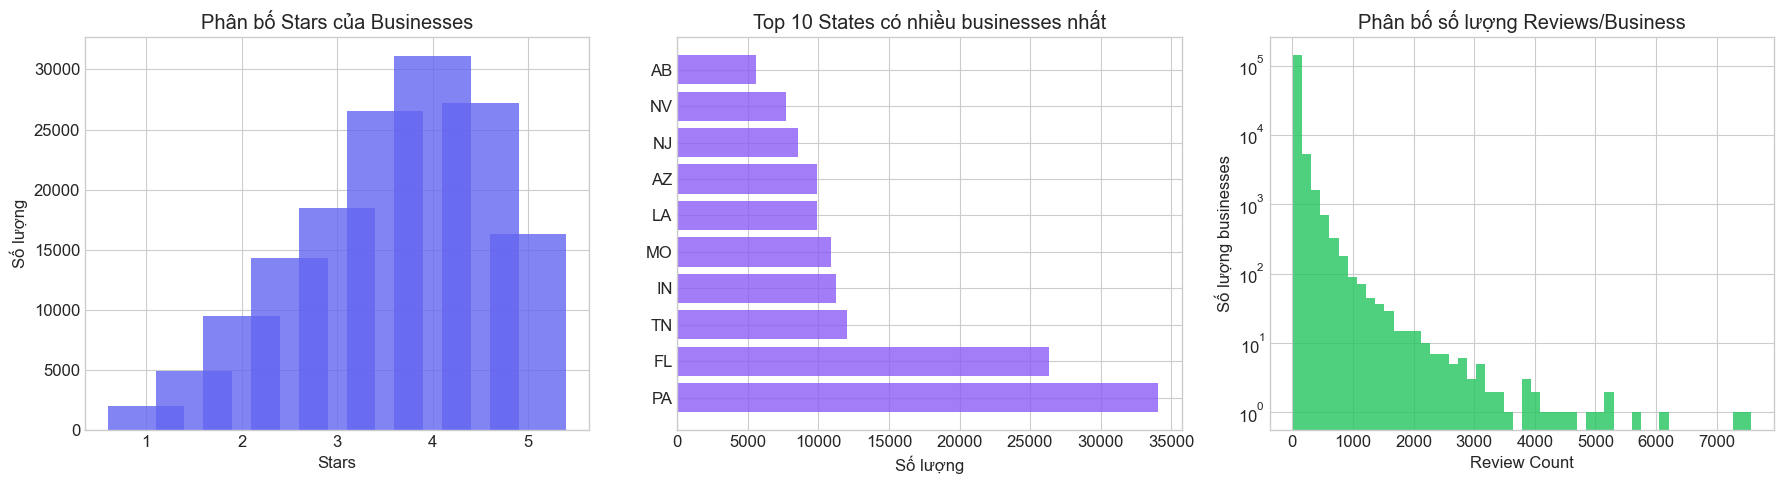

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Phân bố Stars
star_counts = df_biz['stars'].value_counts().sort_index()
axes[0].bar(star_counts.index, star_counts.values, color='#6366f1', alpha=0.8)
axes[0].set_title('Phân bố Stars của Businesses')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Số lượng')

# Top 10 States
top_states = df_biz['state'].value_counts().head(10)
axes[1].barh(top_states.index, top_states.values, color='#8b5cf6', alpha=0.8)
axes[1].set_title('Top 10 States có nhiều businesses nhất')
axes[1].set_xlabel('Số lượng')

# Phân bố Review Count (log scale)
axes[2].hist(df_biz['review_count'], bins=50, color='#22c55e', alpha=0.8)
axes[2].set_title('Phân bố số lượng Reviews/Business')
axes[2].set_xlabel('Review Count')
axes[2].set_ylabel('Số lượng businesses')
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('business_overview.png', dpi=150, bbox_inches='tight')
plt.show()

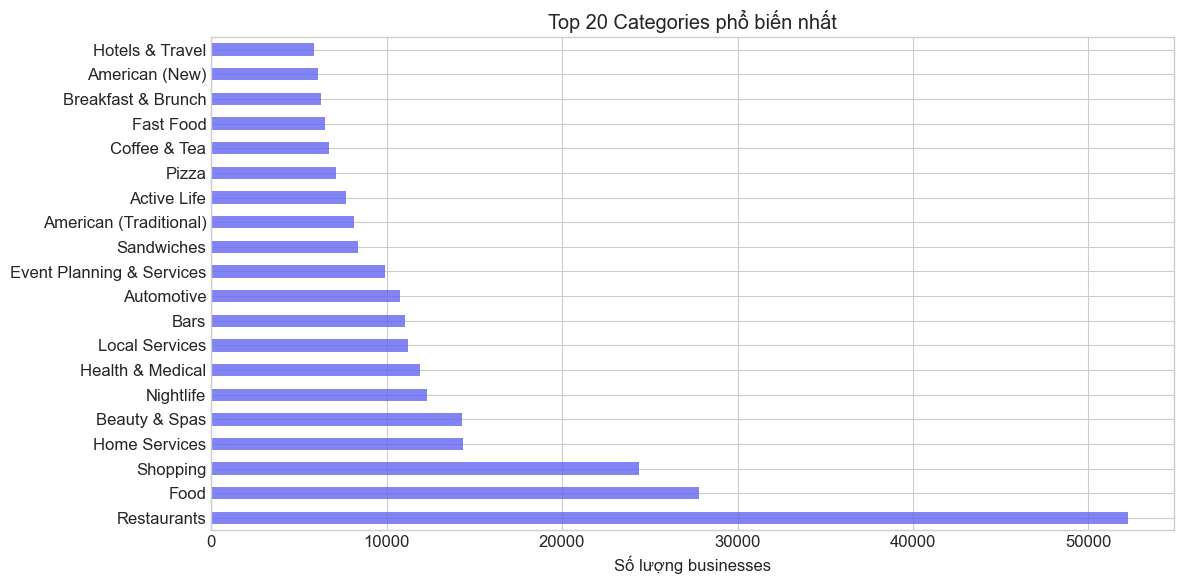


Top 5 categories:
  Restaurants: 52,268
  Food: 27,781
  Shopping: 24,395
  Home Services: 14,356
  Beauty & Spas: 14,292


In [7]:
# Top categories
all_cats = []
for cats in df_biz['categories'].dropna():
    all_cats.extend([c.strip() for c in cats.split(',')])

top_cats = pd.Series(Counter(all_cats)).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
top_cats.plot(kind='barh', color='#6366f1', alpha=0.8)
plt.title('Top 20 Categories phổ biến nhất')
plt.xlabel('Số lượng businesses')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 5 categories:')
for cat, count in top_cats.head(5).items():
    print(f'  {cat}: {count:,}')

In [8]:
# Lọc restaurants (phù hợp với project)
restaurant_keywords = ['Restaurant', 'Food', 'Fast Food', 'Burgers', 'Pizza', 'Sushi']
mask = df_biz['categories'].fillna('').apply(
    lambda x: any(kw.lower() in x.lower() for kw in restaurant_keywords)
)
df_restaurants = df_biz[mask]

print(f'Tổng restaurants/food businesses: {len(df_restaurants):,}')
print(f'Tỉ lệ: {len(df_restaurants)/len(df_biz)*100:.1f}%')
print(f'Stars trung bình (restaurants): {df_restaurants["stars"].mean():.2f}')
print(f'Reviews/restaurant (avg): {df_restaurants["review_count"].mean():.1f}')

Tổng restaurants/food businesses: 64,629
Tỉ lệ: 43.0%
Stars trung bình (restaurants): 3.55
Reviews/restaurant (avg): 76.6


## 3. Review Dataset Analysis

In [9]:
# Thống kê cơ bản
df_rev['text_length'] = df_rev['text'].str.len()
df_rev['word_count']  = df_rev['text'].str.split().str.len()
df_rev['date']        = pd.to_datetime(df_rev['date'])
df_rev['year']        = df_rev['date'].dt.year

print('=== THỐNG KÊ REVIEWS ===')
print(f'Tổng reviews sample   : {len(df_rev):,}')
print(f'Stars trung bình      : {df_rev["stars"].mean():.2f}')
print(f'Độ dài TB (ký tự)     : {df_rev["text_length"].mean():.0f}')
print(f'Độ dài TB (từ)        : {df_rev["word_count"].mean():.0f}')
print(f'Review ngắn nhất      : {df_rev["text_length"].min()} ký tự')
print(f'Review dài nhất       : {df_rev["text_length"].max()} ký tự')
print(f'Năm bắt đầu           : {df_rev["year"].min()}')
print(f'Năm gần nhất          : {df_rev["year"].max()}')

=== THỐNG KÊ REVIEWS ===
Tổng reviews sample   : 50,000
Stars trung bình      : 3.85
Độ dài TB (ký tự)     : 547
Độ dài TB (từ)        : 101
Review ngắn nhất      : 3 ký tự
Review dài nhất       : 4997 ký tự
Năm bắt đầu           : 2005
Năm gần nhất          : 2018


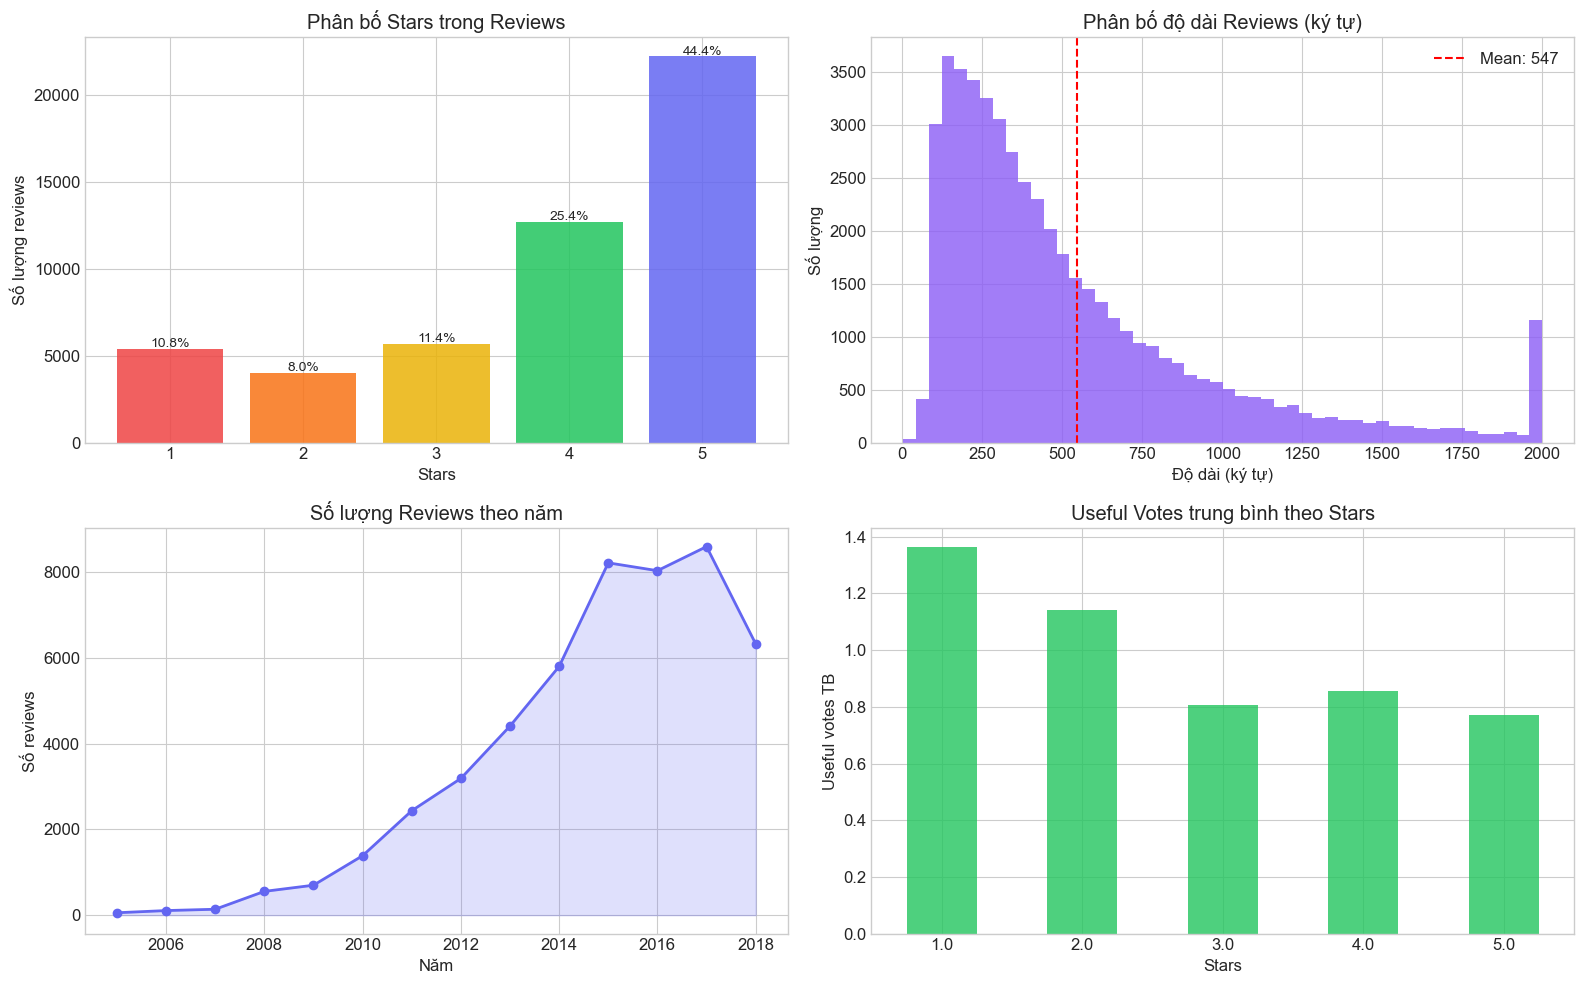

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Phân bố Stars
star_rev = df_rev['stars'].value_counts().sort_index()
colors = ['#ef4444', '#f97316', '#eab308', '#22c55e', '#6366f1']
axes[0,0].bar(star_rev.index, star_rev.values, color=colors, alpha=0.85)
axes[0,0].set_title('Phân bố Stars trong Reviews')
axes[0,0].set_xlabel('Stars')
axes[0,0].set_ylabel('Số lượng reviews')
for i, (k, v) in enumerate(star_rev.items()):
    axes[0,0].text(k, v + 100, f'{v/len(df_rev)*100:.1f}%',
                   ha='center', fontsize=10)

# Phân bố độ dài review
axes[0,1].hist(df_rev['text_length'].clip(0, 2000), bins=50,
               color='#8b5cf6', alpha=0.8)
axes[0,1].set_title('Phân bố độ dài Reviews (ký tự)')
axes[0,1].set_xlabel('Độ dài (ký tự)')
axes[0,1].set_ylabel('Số lượng')
axes[0,1].axvline(df_rev['text_length'].mean(), color='red',
                   linestyle='--', label=f'Mean: {df_rev["text_length"].mean():.0f}')
axes[0,1].legend()

# Reviews theo năm
year_counts = df_rev['year'].value_counts().sort_index()
axes[1,0].plot(year_counts.index, year_counts.values,
               marker='o', color='#6366f1', linewidth=2)
axes[1,0].fill_between(year_counts.index, year_counts.values,
                        alpha=0.2, color='#6366f1')
axes[1,0].set_title('Số lượng Reviews theo năm')
axes[1,0].set_xlabel('Năm')
axes[1,0].set_ylabel('Số reviews')

# Useful votes theo stars
df_rev.groupby('stars')['useful'].mean().plot(
    kind='bar', ax=axes[1,1], color='#22c55e', alpha=0.8
)
axes[1,1].set_title('Useful Votes trung bình theo Stars')
axes[1,1].set_xlabel('Stars')
axes[1,1].set_ylabel('Useful votes TB')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('review_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Phân tích reviews ngắn (có thể bị lọc bởi Data Validator)
short_reviews = df_rev[df_rev['text_length'] < 10]
print(f'Reviews < 10 ký tự: {len(short_reviews):,} ({len(short_reviews)/len(df_rev)*100:.2f}%)')
print('\nVí dụ reviews ngắn:')
for text in short_reviews['text'].head(5).values:
    print(f'  "{text}"')

# Reviews sau khi qua validator
valid_reviews = df_rev[
    (df_rev['text_length'] >= 10) &
    (df_rev['text_length'] <= 5000) &
    (df_rev['stars'].between(1, 5))
]
print(f'\nReviews hợp lệ sau Validator: {len(valid_reviews):,} '
      f'({len(valid_reviews)/len(df_rev)*100:.1f}%)')

Reviews < 10 ký tự: 1 (0.00%)

Ví dụ reviews ngắn:
  "Boo"

Reviews hợp lệ sau Validator: 49,999 (100.0%)


## 4. Sentiment Label Distribution

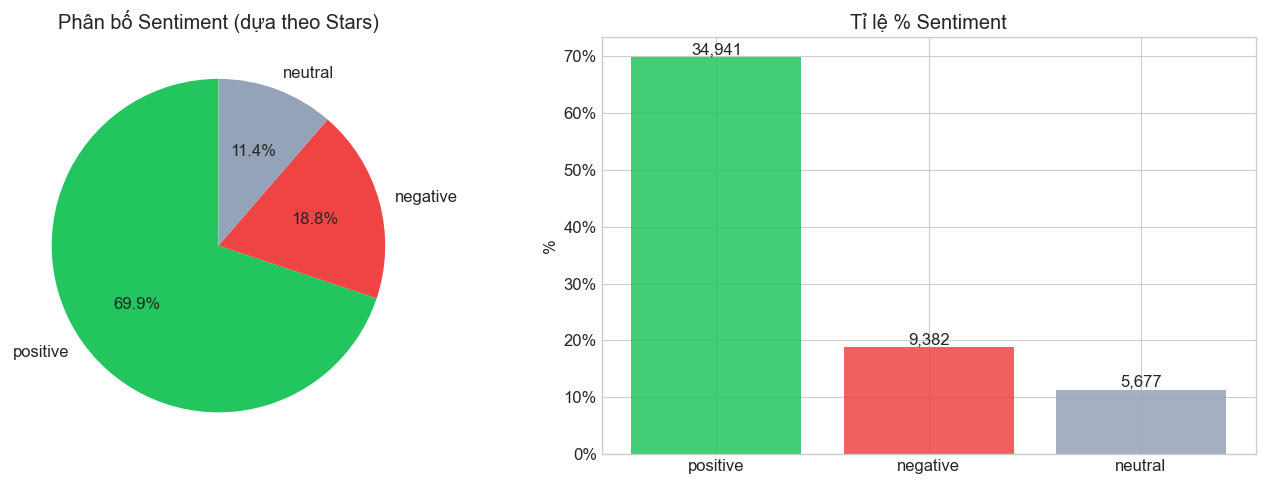

Phân bố sentiment:
  positive: 34,941 (69.9%)
  negative: 9,382 (18.8%)
  neutral: 5,677 (11.4%)


In [12]:
# Dùng stars làm proxy cho sentiment (ground truth)
def stars_to_sentiment(stars):
    if stars >= 4:
        return 'positive'
    elif stars <= 2:
        return 'negative'
    else:
        return 'neutral'

df_rev['sentiment_label'] = df_rev['stars'].apply(stars_to_sentiment)
sentiment_dist = df_rev['sentiment_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#22c55e', '#ef4444', '#94a3b8']
axes[0].pie(
    sentiment_dist.values,
    labels=sentiment_dist.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
)
axes[0].set_title('Phân bố Sentiment (dựa theo Stars)')

# Bar chart với %
axes[1].bar(
    sentiment_dist.index,
    sentiment_dist.values / len(df_rev) * 100,
    color=colors, alpha=0.85
)
axes[1].set_title('Tỉ lệ % Sentiment')
axes[1].set_ylabel('%')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (label, count) in enumerate(sentiment_dist.items()):
    axes[1].text(i, count/len(df_rev)*100 + 0.5,
                 f'{count:,}', ha='center')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Phân bố sentiment:')
for label, count in sentiment_dist.items():
    print(f'  {label}: {count:,} ({count/len(df_rev)*100:.1f}%)')

## 5. Text Analysis

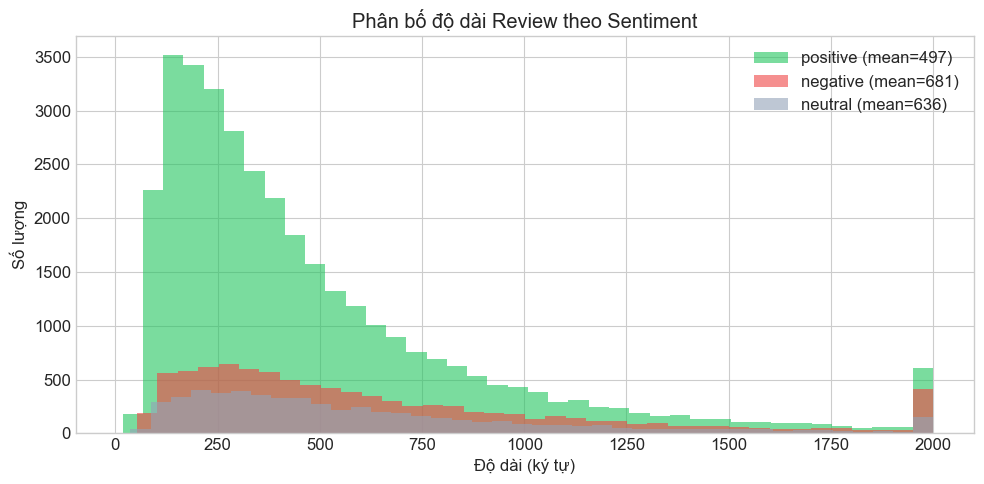

In [13]:
# Độ dài review theo sentiment
fig, ax = plt.subplots(figsize=(10, 5))
for sentiment, color in zip(['positive', 'negative', 'neutral'],
                              ['#22c55e', '#ef4444', '#94a3b8']):
    subset = df_rev[df_rev['sentiment_label'] == sentiment]['text_length']
    ax.hist(subset.clip(0, 2000), bins=40, alpha=0.6,
            label=f'{sentiment} (mean={subset.mean():.0f})', color=color)

ax.set_title('Phân bố độ dài Review theo Sentiment')
ax.set_xlabel('Độ dài (ký tự)')
ax.set_ylabel('Số lượng')
ax.legend()
plt.tight_layout()
plt.savefig('text_length_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

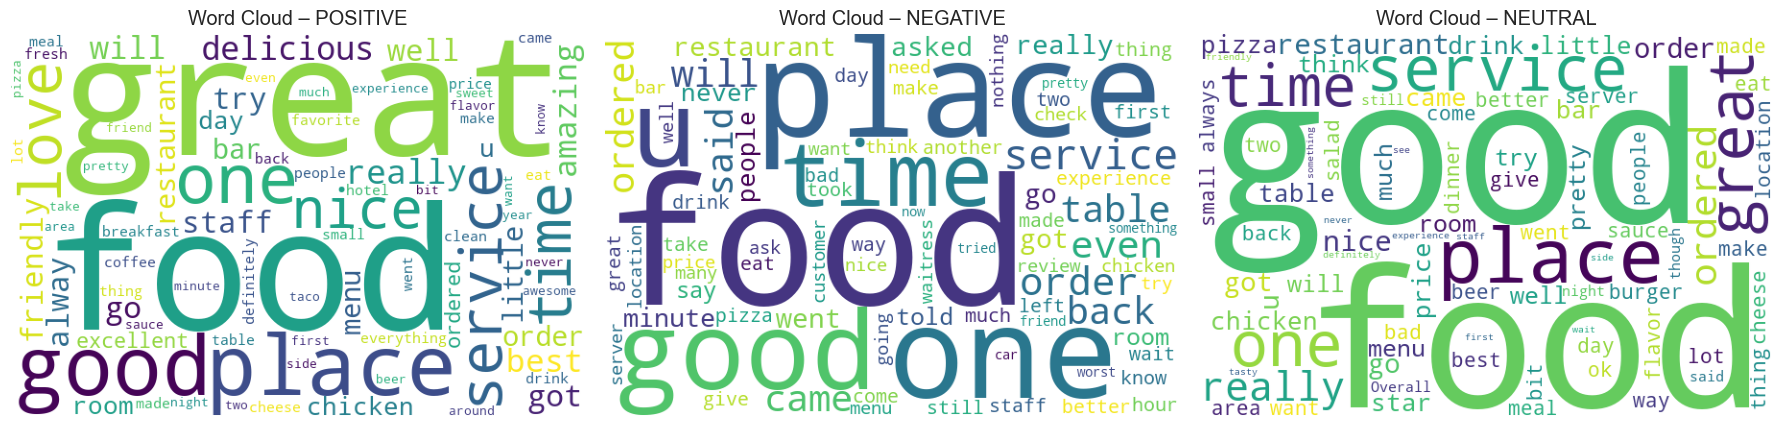

In [14]:
# Word Cloud
try:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, sentiment, color in zip(
        axes,
        ['positive', 'negative', 'neutral'],
        ['#22c55e', '#ef4444', '#94a3b8']
    ):
        text = ' '.join(
            df_rev[df_rev['sentiment_label'] == sentiment]['text']
            .sample(min(500, len(df_rev)), random_state=42)
        )
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap='viridis',
            max_words=80
        ).generate(text)
        ax.imshow(wc)
        ax.set_title(f'Word Cloud – {sentiment.upper()}')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('⚠️  Cần cài wordcloud: pip install wordcloud')

## 6. Pipeline Impact Analysis

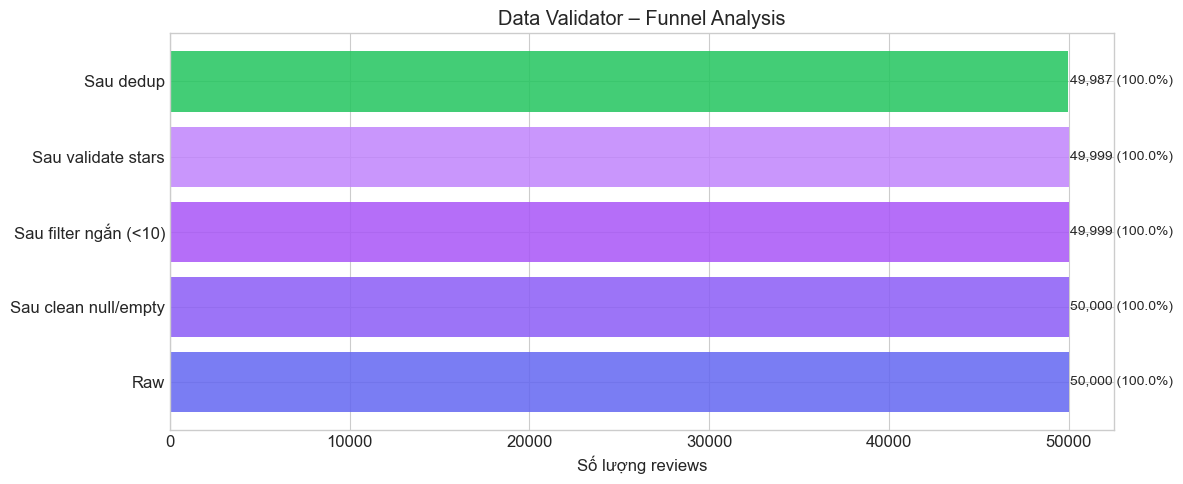

Funnel analysis:
  Raw: 50,000 (100.0%)
  Sau clean null/empty: 50,000 (100.0%)
  Sau filter ngắn (<10): 49,999 (100.0%)
  Sau validate stars: 49,999 (100.0%)
  Sau dedup: 49,987 (100.0%)


In [15]:
# Mô phỏng tác động của từng bước trong Data Validator
total = len(df_rev)
stages = {}

# Sau clean text
after_clean = df_rev.dropna(subset=['text'])
after_clean = after_clean[after_clean['text'].str.strip() != '']
stages['Raw'] = total
stages['Sau clean null/empty'] = len(after_clean)

# Sau filter ngắn
after_short = after_clean[after_clean['text'].str.len() >= 10]
stages['Sau filter ngắn (<10)'] = len(after_short)

# Sau validate stars
after_stars = after_short[after_short['stars'].between(1, 5)]
stages['Sau validate stars'] = len(after_stars)

# Sau dedup
after_dedup = after_stars.drop_duplicates(subset=['text'])
stages['Sau dedup'] = len(after_dedup)

# Vẽ funnel
fig, ax = plt.subplots(figsize=(12, 5))
colors_funnel = ['#6366f1', '#8b5cf6', '#a855f7', '#c084fc', '#22c55e']
bars = ax.barh(
    list(stages.keys()),
    list(stages.values()),
    color=colors_funnel, alpha=0.85
)
ax.set_title('Data Validator – Funnel Analysis')
ax.set_xlabel('Số lượng reviews')

for bar, (stage, count) in zip(bars, stages.items()):
    pct = count / total * 100
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{count:,} ({pct:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('validator_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print('Funnel analysis:')
for stage, count in stages.items():
    print(f'  {stage}: {count:,} ({count/total*100:.1f}%)')

## 7. Insights & Kết luận

In [16]:
print('=' * 60)
print('📊 INSIGHTS TỪ EDA')
print('=' * 60)

pos_pct = len(df_rev[df_rev['sentiment_label']=='positive'])/len(df_rev)*100
neg_pct = len(df_rev[df_rev['sentiment_label']=='negative'])/len(df_rev)*100
neu_pct = len(df_rev[df_rev['sentiment_label']=='neutral'])/len(df_rev)*100

print(f'''
1. DATASET SIZE
   - Tổng businesses : {len(df_biz):,}
   - Tổng reviews    : {len(df_rev):,} (sample)
   - Restaurants     : {len(df_restaurants):,} ({len(df_restaurants)/len(df_biz)*100:.1f}%)

2. SENTIMENT DISTRIBUTION (ground truth từ stars)
   - Positive (4-5★) : {pos_pct:.1f}%
   - Negative (1-2★) : {neg_pct:.1f}%
   - Neutral  (3★)   : {neu_pct:.1f}%
   → Dataset bị mất cân bằng (imbalanced) về phía positive

3. REVIEW QUALITY
   - Độ dài TB       : {df_rev['text_length'].mean():.0f} ký tự
   - Reviews < 10 ký : {len(df_rev[df_rev['text_length']<10])/len(df_rev)*100:.2f}% → Validator xử lý
   - Batch size 100  : phù hợp, tránh vượt token limit Groq

4. CHO PIPELINE
   - Nên dùng businesses có >= 100 reviews để đủ tin cậy
   - Negative reviews thường dài hơn positive → nhiều thông tin hơn
   - Dataset tập trung ở US → cần Google Maps cho quán Việt Nam
''')

📊 INSIGHTS TỪ EDA

1. DATASET SIZE
   - Tổng businesses : 150,346
   - Tổng reviews    : 50,000 (sample)
   - Restaurants     : 64,629 (43.0%)

2. SENTIMENT DISTRIBUTION (ground truth từ stars)
   - Positive (4-5★) : 69.9%
   - Negative (1-2★) : 18.8%
   - Neutral  (3★)   : 11.4%
   → Dataset bị mất cân bằng (imbalanced) về phía positive

3. REVIEW QUALITY
   - Độ dài TB       : 547 ký tự
   - Reviews < 10 ký : 0.00% → Validator xử lý
   - Batch size 100  : phù hợp, tránh vượt token limit Groq

4. CHO PIPELINE
   - Nên dùng businesses có >= 100 reviews để đủ tin cậy
   - Negative reviews thường dài hơn positive → nhiều thông tin hơn
   - Dataset tập trung ở US → cần Google Maps cho quán Việt Nam

